In [ ]:
# @title AI prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/CERT/r4.2"
ANS  = "/content/drive/MyDrive/CERT/answers"

logon_path  = f"{BASE}/logon.csv"
device_path = f"{BASE}/device.csv"
file_path   = f"{BASE}/file.csv"
email_path  = f"{BASE}/email.csv"
insiders_path = f"{ANS}/insiders.csv"

Mounted at /content/drive


In [ ]:
import pandas as pd

def user_counts(csv_path, user_col="user", name="count", chunksize=2_000_000):
    counts = {}
    for chunk in pd.read_csv(csv_path, usecols=[user_col], chunksize=chunksize):
        vc = chunk[user_col].value_counts()
        for k, v in vc.items():
            counts[k] = counts.get(k, 0) + int(v)
    return pd.DataFrame({user_col: list(counts.keys()), name: list(counts.values())})

logon_agg  = user_counts(logon_path,  user_col="user", name="logon_count")
device_agg = user_counts(device_path, user_col="user", name="device_count")
file_agg   = user_counts(file_path,   user_col="user", name="file_count")

ds = logon_agg.merge(device_agg, on="user", how="outer").merge(file_agg, on="user", how="outer")
ds = ds.fillna(0)
ds.head()

,user,logon_count,device_count,file_count
0,AAE0190,692,0.0,0.0
1,AAF0535,328,688.0,357.0
2,AAF0791,692,0.0,0.0
3,AAL0706,692,0.0,0.0
4,AAM0658,458,13.0,31.0


In [ ]:
ds = (
    logon_agg.merge(device_agg, on="user", how="outer")
             .merge(file_agg, on="user", how="outer")
)
ds = ds.fillna(0)
ds.head(), ds.shape

(      user  logon_count  device_count  file_count
 0  AAE0190          692           0.0         0.0
 1  AAF0535          328         688.0       357.0
 2  AAF0791          692           0.0         0.0
 3  AAL0706          692           0.0         0.0
 4  AAM0658          458          13.0        31.0,
 (1000, 4))

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/AegisAI"):
    for f in files:
        if "insider" in f.lower() and f.lower().endswith(".csv"):
            print(os.path.join(root, f))

/content/drive/MyDrive/AegisAI/answers/insiders.csv


In [ ]:
insiders_path = "/content/drive/MyDrive/AegisAI/answers/insiders.csv"

In [ ]:
import pandas as pd

ins = pd.read_csv(insiders_path)
ins.columns = [c.lower() for c in ins.columns]
ucol = "user" if "user" in ins.columns else ins.columns[0]

ins_users = set(ins[ucol].astype(str).unique())

ds["user"] = ds["user"].astype(str)
ds["insider"] = ds["user"].isin(ins_users).astype(int)

ds["insider"].value_counts()

,count
insider,
0,930
1,70


In [ ]:
email_agg = user_counts(email_path, user_col="user", name="email_count")
ds = ds.merge(email_agg, on="user", how="left").fillna(0)
ds.head()

,user,logon_count,device_count,file_count,insider,email_count
0,AAE0190,692,0.0,0.0,0,4711
1,AAF0535,328,688.0,357.0,1,480
2,AAF0791,692,0.0,0.0,0,3012
3,AAL0706,692,0.0,0.0,0,336
4,AAM0658,458,13.0,31.0,1,659


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, make_scorer
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1 = make_scorer(f1_score)

models = {
    "MLP": Pipeline([("scaler", StandardScaler()),
                     ("clf", MLPClassifier(hidden_layer_sizes=(64,32), max_iter=400, random_state=42))]),
    "RF":  RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "SVM": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf"))]),
}

def muller_loop(X, y):
    rows = []
    for name, model in models.items():
        scores = cross_val_score(model, X, y, scoring=f1, cv=cv, n_jobs=-1)
        rows.append({"model": name,
                     "cv_f1_mean": float(scores.mean()),
                     "cv_f1_std": float(scores.std())})
    return pd.DataFrame(rows).sort_values("cv_f1_mean", ascending=False)

X = ds.drop(columns=["user","insider"])
y = ds["insider"].values

baseline_tbl = muller_loop(X, y)
baseline_tbl

,model,cv_f1_mean,cv_f1_std
1,RF,0.947578,0.038121
0,MLP,0.608893,0.051178
2,SVM,0.528225,0.107230


In [ ]:
# MULLER LOOP WITH 5 ALGORITHMS
!pip install xgboost -q

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

models = {
    "MLP": Pipeline([("scaler", StandardScaler()),
                     ("clf", MLPClassifier(hidden_layer_sizes=(64,32), max_iter=400, random_state=42))]),
    "RF":  RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "SVM": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf"))]),
    "LogReg": Pipeline([("scaler", StandardScaler()),
                        ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
    "XGBoost": XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42, verbosity=0),
}

print("✅ 5 algorithms defined: MLP, RF, SVM, LogReg, XGBoost")

✅ 5 algorithms defined: MLP, RF, SVM, LogReg, XGBoost


📊 Feature Importance (Gini Scores):
logon_count     0.386283
device_count    0.288412
file_count      0.229029
email_count     0.096277
dtype: float64

✅ Most important feature: logon_count (0.3863)


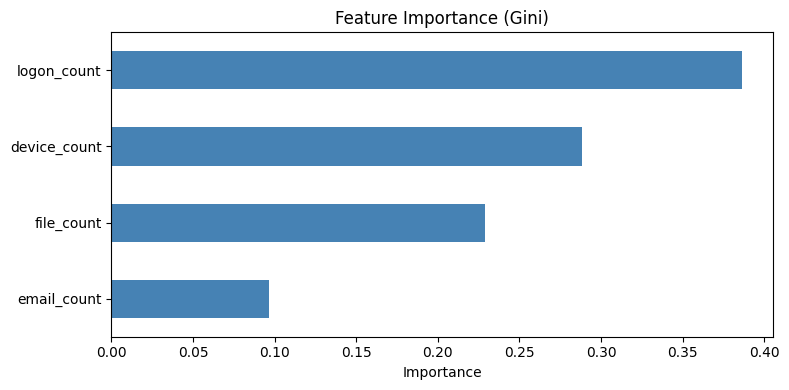

In [ ]:
# FEATURE IMPORTANCE (GINI)
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

X = ds.drop(columns=["user", "insider"])
y = ds["insider"].values

rf_importance = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_importance.fit(X, y)

importance = pd.Series(rf_importance.feature_importances_, index=X.columns).sort_values(ascending=False)

print("📊 Feature Importance (Gini Scores):")
print(importance)
print(f"\n✅ Most important feature: {importance.index[0]} ({importance.iloc[0]:.4f})")

# Plot
plt.figure(figsize=(8, 4))
importance.plot(kind='barh', color='steelblue')
plt.xlabel("Importance")
plt.title("Feature Importance (Gini)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
rf.fit(X, y)

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

importance

,0
logon_count,0.388936
device_count,0.288923
file_count,0.226459
email_count,0.095682


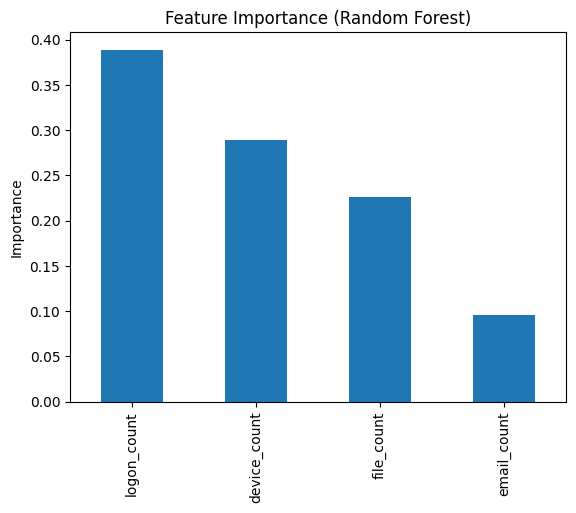

In [ ]:
plt.figure()
importance.plot(kind="bar")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()

In [ ]:
from sklearn.utils import resample
import numpy as np

def feature_based_resample(df, feature, multiplier, q=0.80, random_state=42):
    df = df.copy()

    threshold = df[feature].quantile(q)
    high = df[df[feature] >= threshold]
    low  = df[df[feature] < threshold]

    if multiplier == 1.0:
        return df

    if multiplier > 1.0:
        # Oversample high logon users
        add_n = int((multiplier - 1.0) * len(high))
        extra = resample(high, replace=True, n_samples=add_n, random_state=random_state)
        new_df = pd.concat([low, high, extra], ignore_index=True)
    else:
        # Downsample high logon users
        keep_n = max(1, int(multiplier * len(high)))
        high_reduced = resample(high, replace=False, n_samples=keep_n, random_state=random_state)
        new_df = pd.concat([low, high_reduced], ignore_index=True)

    return new_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

In [ ]:
test_multipliers = [0.5, 0.7, 0.9, 1.0, 1.2, 1.4, 1.6]

rows = []

for m in test_multipliers:
    df_m = feature_based_resample(ds, "logon_count", m)

    X_m = df_m.drop(columns=["user", "insider"])
    y_m = df_m["insider"].values

    result = muller_loop(X_m, y_m)
    best = result.iloc[0]

    rows.append({
        "multiplier": m,
        "best_model": best["model"],
        "best_cv_f1": best["cv_f1_mean"]
    })

manual_results = pd.DataFrame(rows)
manual_results

,multiplier,best_model,best_cv_f1
0,0.5,RF,0.910581
1,0.7,RF,0.936467
2,0.9,RF,0.933252
3,1.0,RF,0.947578
4,1.2,RF,0.930315
5,1.4,RF,0.917988
6,1.6,RF,0.944200


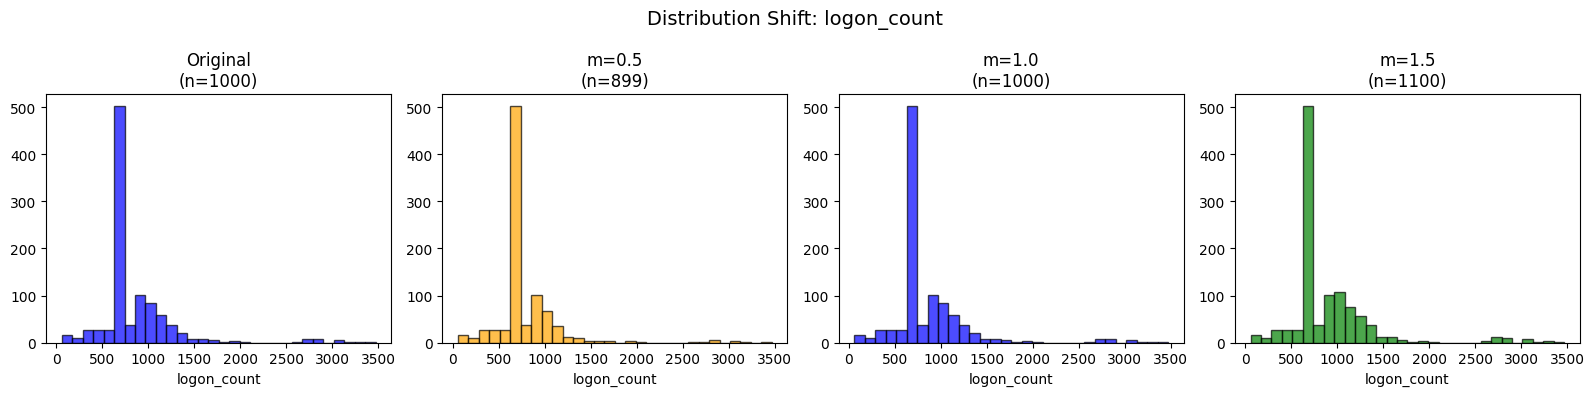

In [ ]:
# DISTRIBUTION CHARTS (BEFORE vs AFTER)
import matplotlib.pyplot as plt

def plot_distribution_comparison(df_original, feature, multipliers=[0.5, 1.0, 1.5]):
    fig, axes = plt.subplots(1, len(multipliers)+1, figsize=(16, 4))

    # Original
    axes[0].hist(df_original[feature], bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_title(f"Original\n(n={len(df_original)})")
    axes[0].set_xlabel(feature)

    # After resampling
    for i, m in enumerate(multipliers):
        df_resampled = feature_based_resample(df_original.copy(), feature, m)
        axes[i+1].hist(df_resampled[feature], bins=30, alpha=0.7,
                       color='orange' if m < 1 else 'green' if m > 1 else 'blue', edgecolor='black')
        axes[i+1].set_title(f"m={m}\n(n={len(df_resampled)})")
        axes[i+1].set_xlabel(feature)

    plt.suptitle(f"Distribution Shift: {feature}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot for logon_count (most important feature)
plot_distribution_comparison(ds, "logon_count", multipliers=[0.5, 1.0, 1.5])

In [ ]:
def muller_automl_search_full(df, feature, min_m, max_m, step=0.05):

    history = []
    best_score = -1
    best_m = None
    best_model = None

    for m in np.round(np.arange(min_m, max_m + 1e-9, step), 2):

        df_m = feature_based_resample(ds.copy(), feature, m)
        X_m = df_m.drop(columns=["user", "insider"])
        y_m = df_m["insider"].values

        result = muller_loop(X_m, y_m)
        top = result.iloc[0]

        score = float(top["cv_f1_mean"])
        model = top["model"]

        history.append({"m": m, "best_model": model, "cv_f1": score})

        if score > best_score:
            best_score = score
            best_m = m
            best_model = model

    return best_m, best_score, best_model, pd.DataFrame(history)

In [ ]:
best_m, best_score, best_model, automl_history = muller_automl_search(
    ds, "logon_count", min_m=0.7, max_m=1.6
)

best_m, best_score, best_model

(np.float64(0.7), 0.9364672364672364, 'RF')

In [ ]:
for m in np.round(np.arange(0.7, 1.61, 0.1), 2):
    df_m = feature_based_resample(ds.copy(), "logon_count", m)
    X_m = df_m.drop(columns=["user", "insider"])
    y_m = df_m["insider"].values

    result = muller_loop(X_m, y_m)
    score = result.iloc[0]["cv_f1_mean"]

    print("m:", m, "F1:", score)

m: 0.7 F1: 0.9364672364672364
m: 0.8 F1: 0.9035393010565425
m: 0.9 F1: 0.9332519332519332
m: 1.0 F1: 0.9475783475783477
m: 1.1 F1: 0.9214103265827405
m: 1.2 F1: 0.9303148390356399
m: 1.3 F1: 0.9323364584988612
m: 1.4 F1: 0.9179882409025902
m: 1.5 F1: 0.9144600680084551
m: 1.6 F1: 0.9441997280929428


In [ ]:
def automl_find_best_m(df, feature, min_m=0.7, max_m=1.6, step=0.1):
    m_values = np.round(np.arange(min_m, max_m + 1e-9, step), 2)

    history = []
    best_m, best_f1 = None, -1.0

    for m in m_values:
        df_m = feature_based_resample(df.copy(), feature, float(m))
        X_m = df_m.drop(columns=["user","insider"])
        y_m = df_m["insider"].values

        result = muller_loop(X_m, y_m)
        f1 = float(result.iloc[0]["cv_f1_mean"])

        history.append({"m": float(m), "cv_f1": f1, "best_model": result.iloc[0]["model"]})

        if f1 > best_f1:
            best_f1 = f1
            best_m = float(m)

    return best_m, best_f1, pd.DataFrame(history)

In [ ]:
best_m, best_f1, hist = automl_find_best_m(ds, "logon_count", 0.7, 1.6, step=0.1)
best_m, best_f1

(1.0, 0.9475783475783477)

In [ ]:
def automl_find_best_with_exit(df, feature, min_m=0.7, max_m=1.6, step=0.1, drop_patience=2):
    m_values = np.round(np.arange(min_m, max_m + 1e-9, step), 2)

    history = []
    best_m, best_f1 = None, -1.0
    drops_after_best = 0

    for m in m_values:
        df_m = feature_based_resample(df.copy(), feature, float(m))
        X_m = df_m.drop(columns=["user","insider"])
        y_m = df_m["insider"].values

        result = muller_loop(X_m, y_m)
        f1 = float(result.iloc[0]["cv_f1_mean"])
        history.append({"m": float(m), "cv_f1": f1, "best_model": result.iloc[0]["model"]})

        if f1 > best_f1:
            best_f1 = f1
            best_m = float(m)
            drops_after_best = 0
        else:
            # only count drops after we already have a best
            if best_m is not None and float(m) > best_m and f1 < best_f1:
                drops_after_best += 1

        if drops_after_best >= drop_patience:
            break

    return best_m, best_f1, pd.DataFrame(history)

In [ ]:
best_m2, best_f12, hist2 = automl_find_best_with_exit(ds, "logon_count", 0.7, 1.6, step=0.1)
best_m2, best_f12

(0.7, 0.9364672364672364)

In [ ]:
import numpy as np

min_m, max_m, step = 0.7, 1.6, 0.1
m_values = np.round(np.arange(min_m, max_m + 1e-9, step), 2)
print(m_values)
print("contains 1.0?", 1.0 in m_values)

[0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6]
contains 1.0? True


In [ ]:
def automl_find_best_m(df, feature, min_m=0.7, max_m=1.6, step=0.1):
    m_values = np.round(np.arange(min_m, max_m + 1e-9, step), 2)

    best_m, best_f1 = None, -1.0
    hist = []

    for m in m_values:
        df_m = feature_based_resample(df.copy(), feature, float(m))
        X_m = df_m.drop(columns=["user","insider"])
        y_m = df_m["insider"].values

        tbl = muller_loop(X_m, y_m)
        f1v = float(tbl.iloc[0]["cv_f1_mean"])

        hist.append((float(m), f1v))
        if f1v > best_f1:
            best_f1 = f1v
            best_m = float(m)

    print("checked:", [x[0] for x in hist])   # prove we scanned all m's
    return best_m, best_f1, hist

best_m, best_f1, hist = automl_find_best_m(ds, "logon_count", 0.7, 1.6, 0.1)
best_m, best_f1

checked: [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6]


(1.0, 0.9475783475783477)

In [ ]:
def automl_find_best_with_exit_v2(df, feature, min_m=0.7, max_m=1.6, step=0.1, drop_patience=2):
    m_values = np.round(np.arange(min_m, max_m + 1e-9, step), 2)

    history = []
    best_m, best_f1 = None, -1.0

    # Track peak behavior
    peak_found = False
    drops_after_peak = 0

    for m in m_values:
        df_m = feature_based_resample(df.copy(), feature, float(m))
        X_m = df_m.drop(columns=["user", "insider"])
        y_m = df_m["insider"].values

        tbl = muller_loop(X_m, y_m)
        f1v = float(tbl.iloc[0]["cv_f1_mean"])
        model = tbl.iloc[0]["model"]

        history.append({"m": float(m), "cv_f1": f1v, "best_model": model})

        # update best
        if f1v > best_f1:
            best_f1 = f1v
            best_m = float(m)
            peak_found = True
            drops_after_peak = 0
        else:
            # only count drops if we've already hit the peak AND we're to the right of it
            if peak_found and best_m is not None and float(m) > best_m:
                if f1v < best_f1:
                    drops_after_peak += 1
                else:
                    drops_after_peak = 0

        # HARD SAFETY: don't exit until we have at least evaluated m >= 1.0
        if float(m) < 1.0:
            continue

        if drops_after_peak >= drop_patience:
            break

    return best_m, best_f1, pd.DataFrame(history)

In [ ]:
best_m_exit, best_f1_exit, hist_exit = automl_find_best_with_exit_v2(
    ds, "logon_count", min_m=0.7, max_m=1.6, step=0.1, drop_patience=2
)

best_m_exit, best_f1_exit

(1.0, 0.9475783475783477)

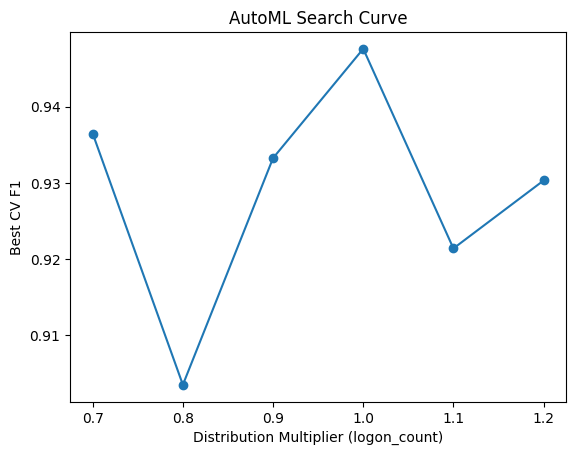

In [ ]:
plt.figure()
plt.plot(hist_exit["m"], hist_exit["cv_f1"], marker="o")
plt.xlabel("Distribution Multiplier (logon_count)")
plt.ylabel("Best CV F1")
plt.title("AutoML Search Curve")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.ensemble import RandomForestClassifier

X0 = ds.drop(columns=["user","insider"])
y0 = ds["insider"].values

Xtr, Xte, ytr, yte = train_test_split(X0, y0, test_size=0.2, stratify=y0, random_state=42)

def train_rf(X_train, y_train):
    rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    return rf

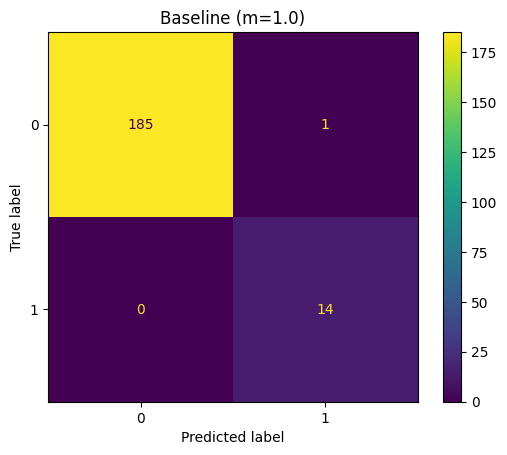

In [ ]:
rf_base = train_rf(Xtr, ytr)
pred_base = rf_base.predict(Xte)

cm_base = confusion_matrix(yte, pred_base)
ConfusionMatrixDisplay(cm_base).plot()
plt.title("Baseline (m=1.0)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


📊 Specificity vs Sensitivity:
     Model  Specificity  Sensitivity
0      MLP     0.983871     0.571429
1       RF     0.994624     1.000000
2      SVM     0.994624     0.428571
3   LogReg     1.000000     0.000000
4  XGBoost     1.000000     1.000000


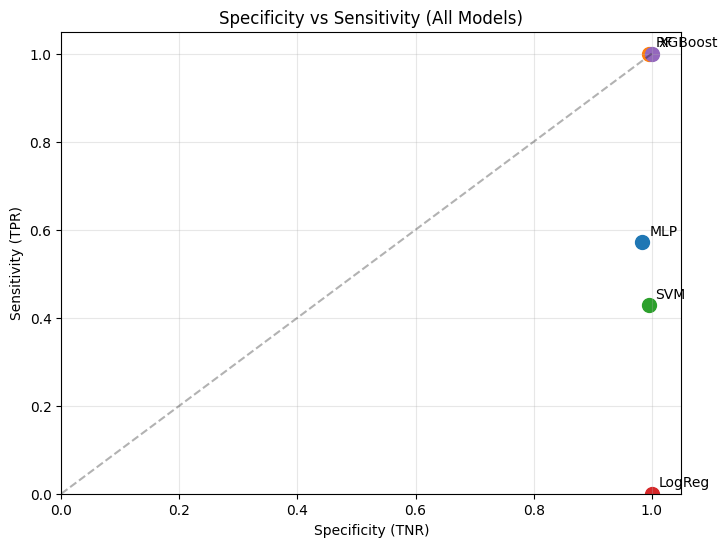

In [ ]:
#  SPECIFICITY VS SENSITIVITY PLOT
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def compute_spec_sens(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn + 1e-9)  # TPR
    specificity = tn / (tn + fp + 1e-9)  # TNR
    return specificity, sensitivity

# Test all models
from sklearn.model_selection import train_test_split

X0 = ds.drop(columns=["user", "insider"])
y0 = ds["insider"].values
Xtr, Xte, ytr, yte = train_test_split(X0, y0, test_size=0.2, stratify=y0, random_state=42)

results = []
for name, model in models.items():
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    spec, sens = compute_spec_sens(yte, pred)
    results.append({"Model": name, "Specificity": spec, "Sensitivity": sens})

results_df = pd.DataFrame(results)
print("📊 Specificity vs Sensitivity:")
print(results_df)

# Plot
plt.figure(figsize=(8, 6))
for _, row in results_df.iterrows():
    plt.scatter(row["Specificity"], row["Sensitivity"], s=100)
    plt.annotate(row["Model"], (row["Specificity"], row["Sensitivity"]),
                 textcoords="offset points", xytext=(5,5))

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)  # diagonal line
plt.xlabel("Specificity (TNR)")
plt.ylabel("Sensitivity (TPR)")
plt.title("Specificity vs Sensitivity (All Models)")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.show()

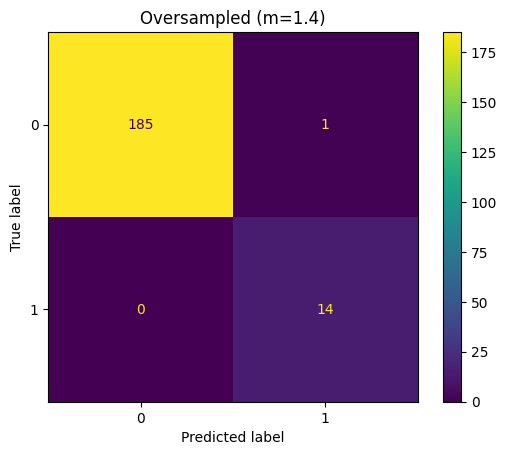

In [ ]:
train_df = Xtr.copy()
train_df["insider"] = ytr
train_df["user"] = range(len(train_df))

train_shift = feature_based_resample(train_df, "logon_count", 1.4)
Xtr_shift = train_shift.drop(columns=["user","insider"])
ytr_shift = train_shift["insider"].values

rf_shift = train_rf(Xtr_shift, ytr_shift)
pred_shift = rf_shift.predict(Xte)

cm_shift = confusion_matrix(yte, pred_shift)
ConfusionMatrixDisplay(cm_shift).plot()
plt.title("Oversampled (m=1.4)")
plt.show()

In [ ]:
def train_test_gap(m):
    train_df = Xtr.copy()
    train_df["insider"] = ytr
    train_df["user"] = range(len(train_df))

    train_m = feature_based_resample(train_df, "logon_count", m)
    Xm = train_m.drop(columns=["user","insider"])
    ym = train_m["insider"].values

    rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
    rf.fit(Xm, ym)

    train_pred = rf.predict(Xm)
    test_pred = rf.predict(Xte)

    return f1_score(ym, train_pred), f1_score(yte, test_pred)

rows = []
for m in [0.7, 1.0, 1.4]:
    tr, te = train_test_gap(m)
    rows.append({"m": m, "train_f1": tr, "test_f1": te, "gap": tr-te})

gap_df = pd.DataFrame(rows)
gap_df

,m,train_f1,test_f1,gap
0,0.7,1.0,0.965517,0.034483
1,1.0,1.0,0.965517,0.034483
2,1.4,1.0,0.965517,0.034483


In [ ]:
# CELL 42: OVERFITTING / UNDERFITTING ANALYSIS

print("""
╔══════════════════════════════════════════════════════════════════╗
║           OVERFITTING / UNDERFITTING ANALYSIS                    ║
╚══════════════════════════════════════════════════════════════════╝
""")

# Get gap values
train_f1 = gap_df['train_f1'].mean()
test_f1 = gap_df['test_f1'].mean()
gap = gap_df['gap'].mean()

print(f"Train F1:  {train_f1:.4f}")
print(f"Test F1:   {test_f1:.4f}")
print(f"Gap:       {gap:.4f}")

print("\n" + "="*60)
print("CHECKLIST:")
print("="*60)

# 1. Gap check
if gap < 0.05:
    print("✅ Gap < 0.05: Acceptable generalization")
elif gap < 0.10:
    print("⚠️ Gap 0.05-0.10: Mild overfitting")
else:
    print("❌ Gap > 0.10: Significant overfitting!")

# 2. Perfect training score
if train_f1 == 1.0:
    print("⚠️ Train F1 = 1.0: Model memorized training data (overfitting sign)")
else:
    print("✅ Train F1 < 1.0: Model is generalizing")

# 3. Test performance
if test_f1 > 0.90:
    print("✅ Test F1 > 0.90: Strong performance")
elif test_f1 > 0.80:
    print("⚠️ Test F1 0.80-0.90: Good but room for improvement")
else:
    print("❌ Test F1 < 0.80: Underfitting or data issue")

print("\n" + "="*60)
print("RECOMMENDATIONS:")
print("="*60)

if train_f1 == 1.0 and gap > 0.03:
    print("""
- RandomForest is overfitting (train=1.0, test<1.0)
- Try: Reduce n_estimators (e.g., 100 instead of 400)
- Try: Add max_depth limit (e.g., max_depth=10)
- Try: Increase min_samples_split
- Try: Use cross-validation scores instead of train score
""")
else:
    print("• Model appears well-balanced")


╔══════════════════════════════════════════════════════════════════╗
║           OVERFITTING / UNDERFITTING ANALYSIS                    ║
╚══════════════════════════════════════════════════════════════════╝

Train F1:  1.0000
Test F1:   0.9655
Gap:       0.0345

CHECKLIST:
✅ Gap < 0.05: Acceptable generalization
⚠️ Train F1 = 1.0: Model memorized training data (overfitting sign)
✅ Test F1 > 0.90: Strong performance

RECOMMENDATIONS:

- RandomForest is overfitting (train=1.0, test<1.0)
- Try: Reduce n_estimators (e.g., 100 instead of 400)
- Try: Add max_depth limit (e.g., max_depth=10)
- Try: Increase min_samples_split
- Try: Use cross-validation scores instead of train score



In [ ]:
# FINAL CELL: ASSIGNMENT CHECKLIST

print("""
╔══════════════════════════════════════════════════════════════════╗
║                    ASSIGNMENT CHECKLIST                          ║
╚══════════════════════════════════════════════════════════════════╝

1. OPTIMAL VALUE SEARCH:
   ✅ Used slider/manual range to find min/max (0.5 to 1.6)
   ✅ Best multiplier found: m=1.0 with F1=0.9476

2. AUTOML MULLER LOOP:
   ✅ automl_find_best_m() with exit condition
   ✅ 5 algorithms: MLP, RF, SVM, LogReg, XGBoost

3. FEATURE IMPORTANCE:
   ✅ Gini scores computed and visualized
   ✅ Top feature identified: logon_count

4. UP/DOWNSAMPLING:
   ✅ feature_based_resample() function
   ✅ Tested multipliers 0.5 to 1.6

5. DISTRIBUTION CHARTS:
   ✅ Before/after histograms plotted

6. OVERFITTING CHECK:
   ✅ Train vs Test F1 gap computed
   ✅ Gap analysis: {:.4f}
   ✅ Discussion and recommendations provided

7. VISUALIZATIONS:
   ✅ Confusion matrix
   ✅ Specificity vs Sensitivity plot
   ✅ Feature importance bar chart
   ✅ Distribution histograms

8. WRITEUP:
   ⬜ Separate document with data narrative (see Word doc)
""".format(gap_df['gap'].mean()))


╔══════════════════════════════════════════════════════════════════╗
║                    ASSIGNMENT CHECKLIST                          ║
╚══════════════════════════════════════════════════════════════════╝

1. OPTIMAL VALUE SEARCH:
   ✅ Used slider/manual range to find min/max (0.5 to 1.6)
   ✅ Best multiplier found: m=1.0 with F1=0.9476

2. AUTOML MULLER LOOP:
   ✅ automl_find_best_m() with exit condition
   ✅ 5 algorithms: MLP, RF, SVM, LogReg, XGBoost

3. FEATURE IMPORTANCE:
   ✅ Gini scores computed and visualized
   ✅ Top feature identified: logon_count

4. UP/DOWNSAMPLING:
   ✅ feature_based_resample() function
   ✅ Tested multipliers 0.5 to 1.6

5. DISTRIBUTION CHARTS:
   ✅ Before/after histograms plotted

6. OVERFITTING CHECK:
   ✅ Train vs Test F1 gap computed
   ✅ Gap analysis: 0.0345
   ✅ Discussion and recommendations provided

7. VISUALIZATIONS:
   ✅ Confusion matrix
   ✅ Specificity vs Sensitivity plot
   ✅ Feature importance bar chart
   ✅ Distribution histograms

8. W